<a href="https://colab.research.google.com/github/rishabh552/Tree-Species-Classification/blob/main/TreeClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/rishabh552/Tree-Species-Classification.git

fatal: destination path 'Tree-Species-Classification' already exists and is not an empty directory.


In [2]:
import os

repo_path = "Tree-Species-Classification/Tree_Species_Dataset"  # Adjust if cloned to a different name
print("Contents:", os.listdir(repo_path))

Contents: ['asopalav', 'simlo', 'garmalo', 'jamun', 'pilikaren', 'other', 'neem', 'coconut', 'gulmohor', 'babul', 'pipal', 'motichanoti', 'cactus', 'sugarcane', 'amla', 'banyan', 'kanchan', 'champa', 'sitafal', 'khajur', 'saptaparni', 'vad', 'sonmahor', 'kesudo', 'bili', 'mango', 'bamboo', 'shirish', 'gunda', 'nilgiri']


In [3]:
class_dirs = os.listdir(repo_path)
print(f"Number of classes: {len(class_dirs)}")

Number of classes: 30


In [4]:
import glob

image_paths = []
labels = []

for class_name in os.listdir(repo_path):
    class_folder = os.path.join(repo_path, class_name)
    if os.path.isdir(class_folder):
        for img_file in os.listdir(class_folder):
            image_paths.append(os.path.join(class_folder, img_file))
            labels.append(class_name)

print(f"Total images: {len(image_paths)}")

Total images: 1454


In [5]:
import pandas as pd

class_counts = {cls: len(os.listdir(os.path.join(repo_path, cls))) for cls in class_dirs}
class_counts_df = pd.DataFrame.from_dict(class_counts, orient='index', columns=['Image Count'])
print(class_counts_df.sort_values('Image Count', ascending=False).head())
print("shape: ",class_counts_df.shape)

          Image Count
other             150
asopalav           50
simlo              50
garmalo            50
jamun              50
shape:  (30, 1)


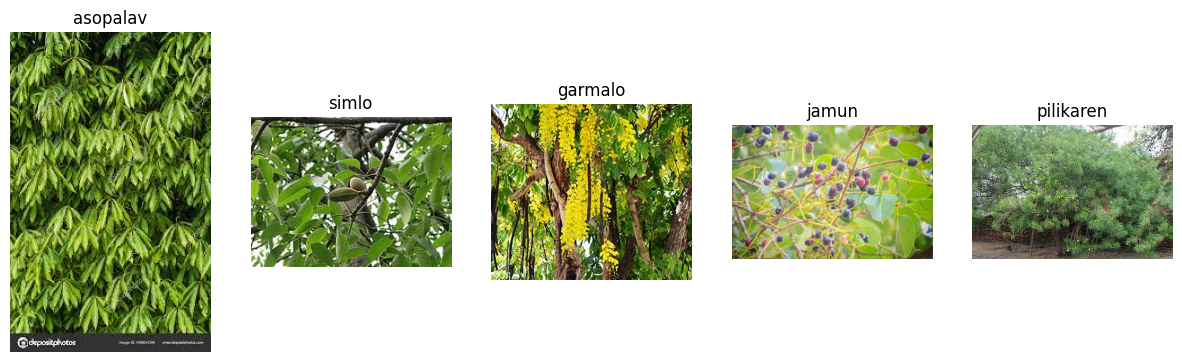

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

def show_sample_images(repo_path, class_dirs, n=5):
    plt.figure(figsize=(15, 10))
    for i, class_dir in enumerate(class_dirs[:n]):
        img_path = os.path.join(repo_path, class_dir, os.listdir(os.path.join(repo_path, class_dir))[0])
        img = Image.open(img_path)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_dir)
        plt.axis('off')
    plt.show()

show_sample_images(repo_path, class_dirs)

In [7]:
image_shapes = []

for class_dir in class_dirs:
    for img_file in os.listdir(os.path.join(repo_path, class_dir)):
        img_path = os.path.join(repo_path, class_dir, img_file)
        img = Image.open(img_path)
        image_shapes.append(img.size)

# DataFrame and Summary
import pandas as pd

shapes_df = pd.DataFrame(image_shapes, columns=["Width", "Height"])
shapes_df.head()

,Width,Height
0,178,284
1,300,168
2,259,194
3,275,183
4,183,275


In [8]:
print(shapes_df.describe())

             Width       Height
count  1600.000000  1600.000000
mean    312.623125   269.821875
std     296.220501   278.014229
min     141.000000   128.000000
25%     225.000000   183.000000
50%     259.000000   200.000000
75%     275.000000   259.000000
max    4000.000000  4032.000000


In [9]:
import hashlib
from collections import defaultdict

hashes = defaultdict(list)

for class_dir in class_dirs:
    for img_file in os.listdir(os.path.join(repo_path, class_dir)):
        img_path = os.path.join(repo_path, class_dir, img_file)
        with open(img_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
            hashes[file_hash].append(img_path)

# Filter duplicates
duplicates = {h: files for h, files in hashes.items() if len(files) > 1}
print("Duplicate image sets found:", len(duplicates))


Duplicate image sets found: 82


In [10]:
corrupt_images = []

for class_dir in class_dirs:
    for img_file in os.listdir(os.path.join(repo_path, class_dir)):
        img_path = os.path.join(repo_path, class_dir, img_file)
        try:
            img = Image.open(img_path)
            img.verify()
        except Exception as e:
            corrupt_images.append(img_path)

print("Corrupted images:", len(corrupt_images))


Corrupted images: 0


Duplicate set 1:


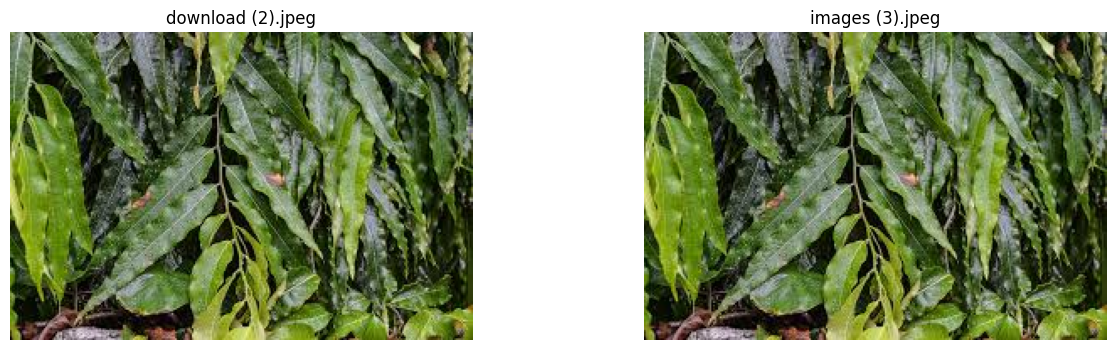

Duplicate set 2:


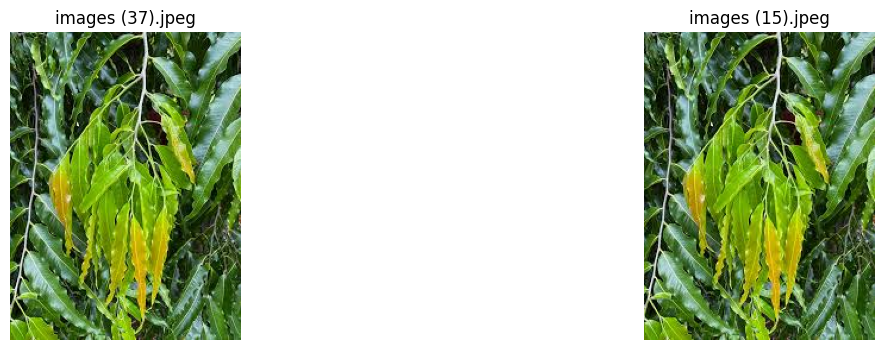

Duplicate set 3:


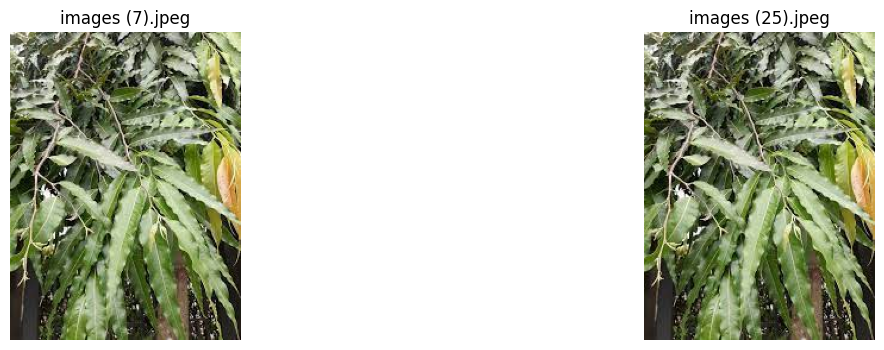

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

def show_duplicate_sets(duplicates, sets_to_display=3):
    shown = 0
    for hash_val, dup_paths in duplicates.items():
        if shown >= sets_to_display:
            break
        print(f"Duplicate set {shown + 1}:")
        plt.figure(figsize=(15, 4))
        for i, img_path in enumerate(dup_paths):
            try:
                img = Image.open(img_path)
                plt.subplot(1, len(dup_paths), i+1)
                plt.imshow(img)
                plt.title(os.path.basename(img_path))
                plt.axis('off')
            except:
                continue
        plt.show()
        shown += 1

show_duplicate_sets(duplicates, sets_to_display=3)

In [12]:
import os

removed_count = 0

for dup_list in duplicates.values():
    # Keep the first, delete rest
    for img_path in dup_list[1:]:
        try:
            os.remove(img_path)
            removed_count += 1
        except Exception as e:
            print(f"Error deleting {img_path}: {e}")

print(f"✅ Removed {removed_count} duplicate images.")


✅ Removed 86 duplicate images.


In [13]:
hashes = defaultdict(list)

for class_dir in class_dirs:
    for img_file in os.listdir(os.path.join(repo_path, class_dir)):
        img_path = os.path.join(repo_path, class_dir, img_file)
        with open(img_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
            hashes[file_hash].append(img_path)

duplicates = {h: files for h, files in hashes.items() if len(files) > 1}
print("🔁 Duplicates remaining:", len(duplicates))

🔁 Duplicates remaining: 0


In [14]:
from PIL import Image
import pandas as pd

# Gather image info
image_info = []

for class_dir in class_dirs:
    class_path = os.path.join(repo_path, class_dir)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                image_info.append({
                    'path': img_path,
                    'width': width,
                    'height': height,
                    'class': class_dir
                })
        except:
            continue

df_sizes = pd.DataFrame(image_info)

# Define thresholds
small_imgs = df_sizes[(df_sizes['width'] < 150) | (df_sizes['height'] < 150)]
large_imgs = df_sizes[(df_sizes['width'] > 1000) | (df_sizes['height'] > 2000)]

print(f"🔻 Very small images: {len(small_imgs)}")
print(f"🔺 Very large images: {len(large_imgs)}")

🔻 Very small images: 20
🔺 Very large images: 40


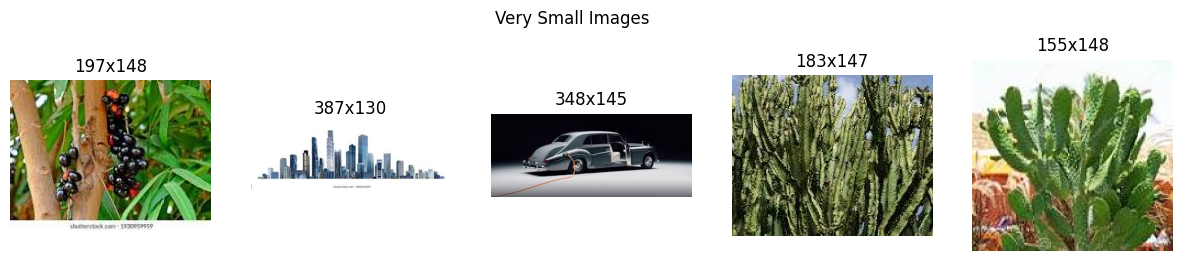

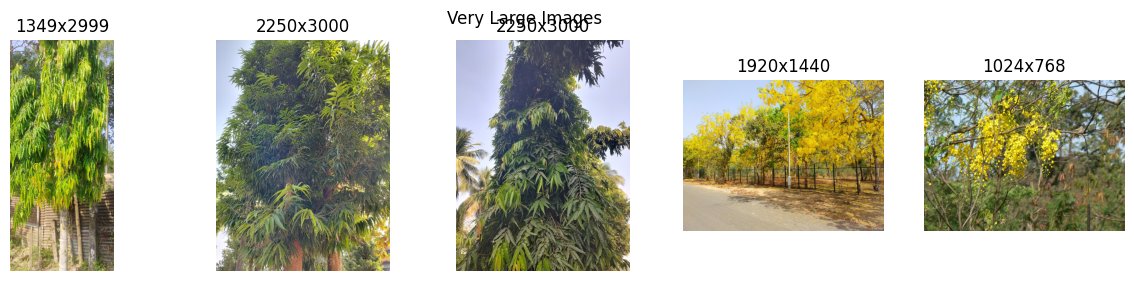

In [15]:
def show_images(df_subset, title, n=5):
    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(df_subset.head(n).iterrows()):
        img = Image.open(row['path'])
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{row['width']}x{row['height']}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(small_imgs, "Very Small Images")
show_images(large_imgs, "Very Large Images")

In [16]:
import os

# Combine both sets
outliers = pd.concat([small_imgs, large_imgs])

# Remove them
removed_count = 0
for path in outliers['path']:
    try:
        os.remove(path)
        removed_count += 1
    except Exception as e:
        print(f"Failed to remove {path}: {e}")

print(f"🗑️ Removed {removed_count} outlier images (small + large).")


🗑️ Removed 60 outlier images (small + large).


In [17]:
image_info = []

for class_dir in class_dirs:
    class_path = os.path.join(repo_path, class_dir)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                image_info.append({
                    'path': img_path,
                    'width': width,
                    'height': height,
                    'class': class_dir
                })
        except:
            continue

df_sizes = pd.DataFrame(image_info)
print(df_sizes[['width', 'height']].describe())

             width       height
count  1454.000000  1454.000000
mean    275.872765   239.044704
std     117.507849   117.197342
min     150.000000   150.000000
25%     225.000000   183.000000
50%     259.000000   198.000000
75%     275.000000   256.000000
max    1000.000000  1247.000000


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Augmentation and rescaling
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    repo_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    repo_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1177 images belonging to 30 classes.
Found 277 images belonging to 30 classes.


In [19]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), weights='imagenet')
base_model.trainable = False  # Freeze base model

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,217,409 (16.09 MB)

 Trainable params: 167,838 (655.62 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [20]:
EPOCHS = 10

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.0474 - loss: 3.4429 - val_accuracy: 0.0903 - val_loss: 3.3845
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 466ms/step - accuracy: 0.0717 - loss: 3.3983 - val_accuracy: 0.0903 - val_loss: 3.3709
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 504ms/step - accuracy: 0.0919 - loss: 3.3928 - val_accuracy: 0.0903 - val_loss: 3.3813
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 477ms/step - accuracy: 0.0819 - loss: 3.3840 - val_accuracy: 0.0903 - val_loss: 3.3718
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 504ms/step - accuracy: 0.0738 - loss: 3.4041 - val_accuracy: 0.0903 - val_loss: 3.3770
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 473ms/step - accuracy: 0.0824 - loss: 3.3929 - val_accuracy: 0.0903 - val_loss: 3.3755
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 504ms/step - accuracy: 0.0804 - loss: 3.3954 - val_accuracy: 0.0903 - val_loss: 3.3696
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 472ms/step - accuracy: 0.0907 - loss: 3.3736 - val_accurac

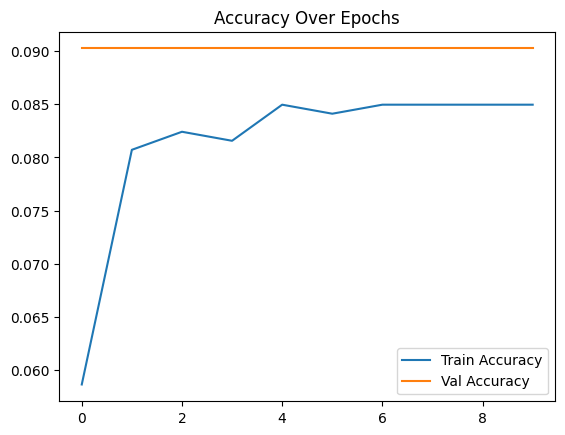

In [21]:
# Plot accuracy/loss curves
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Over Epochs")
plt.show()

# Save model
model.save("tree_species_model.h5")


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(30, activation='softmax')  # For 30 classes
])

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(train_gen, validation_data=val_gen, epochs=10)

model.save("BatchNormalization.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 35s 722ms/step - accuracy: 0.0783 - loss: 5.0381 - val_accuracy: 0.0325 - val_loss: 7.7888
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 512ms/step - accuracy: 0.1054 - loss: 3.2169 - val_accuracy: 0.0325 - val_loss: 15.1233
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 485ms/step - accuracy: 0.1409 - loss: 3.0821 - val_accuracy: 0.0325 - val_loss: 20.5629
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 512ms/step - accuracy: 0.1783 - loss: 2.9628 - val_accuracy: 0.0325 - val_loss: 22.6688
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 501ms/step - accuracy: 0.1276 - loss: 3.0844 - val_accuracy: 0.0325 - val_loss: 23.9123
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 521ms/step - accuracy: 0.1916 - loss: 2.9063 - val_accuracy: 0.0325 - val_loss: 21.2252
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 488ms/step - accuracy: 0.2001 - loss: 2.9128 - val_accuracy: 0.0325 - val_loss: 19.4902
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 518ms/step - accuracy: 0.2071 - loss: 2.8231 - va

In [35]:
import os

dataset_path = '/content/Tree-Species-Classification/Tree_Species_Dataset'  # update to your dataset folder
class_counts = {}

for class_dir in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_dir)
    if os.path.isdir(class_path):
        count = len([name for name in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, name))])
        class_counts[class_dir] = count

# Print counts per class
for class_name, count in class_counts.items():
    print(f'Class: {class_name}, Image Count: {count}')


Class: asopalav, Image Count: 44
Class: simlo, Image Count: 36
Class: garmalo, Image Count: 42
Class: jamun, Image Count: 46
Class: pilikaren, Image Count: 46
Class: other, Image Count: 125
Class: neem, Image Count: 50
Class: coconut, Image Count: 49
Class: gulmohor, Image Count: 43
Class: babul, Image Count: 45
Class: pipal, Image Count: 46
Class: motichanoti, Image Count: 46
Class: cactus, Image Count: 40
Class: sugarcane, Image Count: 50
Class: amla, Image Count: 44
Class: banyan, Image Count: 49
Class: kanchan, Image Count: 47
Class: champa, Image Count: 46
Class: sitafal, Image Count: 44
Class: khajur, Image Count: 49
Class: saptaparni, Image Count: 49
Class: vad, Image Count: 49
Class: sonmahor, Image Count: 49
Class: kesudo, Image Count: 40
Class: bili, Image Count: 44
Class: mango, Image Count: 44
Class: bamboo, Image Count: 50
Class: shirish, Image Count: 49
Class: gunda, Image Count: 49
Class: nilgiri, Image Count: 44


In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Define image dimensions and batch size
img_height, img_width = 224, 224
batch_size = 32

# Enhanced data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load datasets (replace 'repo_path' with your dataset path)
train_generator = train_datagen.flow_from_directory(
    repo_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    repo_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Build the model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3)
)
base_model.trainable = False  # Freeze base model initially

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4),  # Increased dropout to reduce overfitting
    Dense(len(train_generator.class_indices), activation='softmax')
])

# Compile model with initial learning rate
model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks for training
early_stop = EarlyStopping(patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-6)

# Initial training with frozen base model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

# Unfreeze last 30 layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune model
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

# Save the trained model
model.save("mobilenetv2_fine_tuned_enhanced.h5")


Found 1177 images belonging to 30 classes.
Found 277 images belonging to 30 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.0824 - loss: 3.7894 - val_accuracy: 0.2708 - val_loss: 2.7257 - learning_rate: 0.0010
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 469ms/step - accuracy: 0.2568 - loss: 2.6411 - val_accuracy: 0.4043 - val_loss: 2.2045 - learning_rate: 0.0010
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 499ms/step - accuracy: 0.4059 - loss: 2.0498 - val_accuracy: 0.4910 - val_loss: 1.9084 - learning_rate: 0.0010
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 470ms/step - accuracy: 0.4856 - loss: 1.8502 - val_accuracy: 0.5235 - val_loss: 1.7296 - learning_rate: 0.0010
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 500ms/step - accuracy: 0.5348 - loss: 1.5353 - val_accuracy: 0.5740 - val_loss: 1.6104 - learning_rate: 0.0010
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 464ms/step - accuracy: 0.5788 - loss: 1.4587 - val_accuracy: 0.5812 - val_loss: 1.5584 - learning_rate: 0.0010
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 491ms/step - accuracy: 0.6295 - loss: 1.232